# Transaction Categorization pipeline (TF-IDF + Random Forest)

This notebook trains a machine learning model to automatically categorize short transaction descriptions (e.g., "spent 4k on fuel").

It follows a robust Data Science pipeline:
1. **Data Loading & Generation (w/ Outliers)**
2. **Exploratory Data Analysis (EDA)**
3. **Data Cleaning & Text Preprocessing**
4. **Model Training (TF-IDF + Random Forest + GridSearchCV)**
5. **Evaluation & Confusion Matrix**
6. **Real-World API Test (Simulation)**


In [ ]:
!pip install -q scikit-learn pandas numpy joblib matplotlib seaborn nltk

## 1. Data Generation (With Outliers & Noise)
We generate synthetic transaction data and intentionally inject outliers (junk characters, weird languages, ambiguous terms) so the model learns how to handle messy real-world user input without extreme bias.

In [ ]:
import random
import pandas as pd
import numpy as np

categories = {
    "Food": ["lunch", "groceries", "kfc", "dinner", "coffee", "snacks", "supermarket", "pizza", "breakfast", "burger", "meal", "restaurant", "cafe"],
    "Transport": ["fuel", "uber", "bus ticket", "gas", "train", "subway", "tolls", "taxi", "parking", "flight", "transit", "boda"],
    "Housing": ["rent", "mortgage", "plumber", "home depot", "ikea", "apartment", "property tax", "cleaning", "maintenance", "furniture"],
    "Utilities": ["water bill", "electricity", "internet", "phone bill", "gas bill", "trash", "cell plan", "broadband", "power", "wifi"],
    "Entertainment": ["movie", "netflix", "spotify", "concert", "steam", "club", "bowling", "theater", "games", "party", "cinema", "music"],
    "Shopping": ["shoes", "amazon", "target", "clothes", "mall", "jacket", "electronics", "best buy", "shirts", "gifts", "sneakers", "laptop"],
    "Healthcare": ["pharmacy", "doctor", "dentist", "hospital", "vitamins", "first aid", "eye exam", "clinic", "medicine", "therapy", "checkup"]
}

templates = [
    "{keyword}",
    "spent {price} on {keyword}",
    "paid {price} for {keyword}",
    "{keyword} cost me {price}",
    "bought {keyword} for {price}",
    "{keyword} today, {price}",
    "got {keyword} - {price}"
]
data = []
for category, keywords in categories.items():
    for kw in keywords:
        for _ in range(150): # 150 samples per keyword
            price = random.choice([f"{random.randint(1, 100)}k", f"{random.randint(5, 5000)}00", str(random.randint(1, 500))])
            
            # 10% chance to corrupt the text heavily (Outliers/Noise)
            if random.random() < 0.10:
                noise = random.choice(["???", "!!!!!", "...", "---", "1234", np.nan, "ajsdhkjashd", "paid NaN for NaN", "&&&&"])
                text = f"{random.choice(templates).format(keyword=kw, price=price)} {noise}" if pd.notna(noise) else noise
            else:
                if random.random() > 0.8:
                    text = random.choice(["{keyword}", "spent on {keyword}", "paid for {keyword}"]).format(keyword=kw)
                else:
                    text = random.choice(templates).format(keyword=kw, price=price)
                    
            data.append({"text": text.lower() if isinstance(text, str) else text, "label": category})

# Add 200 completely random "Unknown / Uncategorized" Outliers so model doesn't force a fit
for _ in range(200):
    random_outliers = ["transfer to john", "atm withdrawal", "cash", "friend payback", "mystery charge", "fees", "12000"]
    data.append({"text": random.choice(random_outliers), "label": "Other/Unknown"})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Generated {len(df)} records (including noise & outliers).")
display(df.head())


## 2. Exploratory Data Analysis (EDA)
Before training, we must analyze the distribution of our categories and check for any anomalies or missing values.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xticks(rotation=45)
plt.show()

print("Total Records:", len(df))
print("\nMissing Labels Check:")
print(df.isnull().sum())

# Check for empty string inputs
empty_strings = df[df['text'].str.strip() == '']
print(f"\nFound {len(empty_strings)} records with completely empty text descriptions.")

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load dataset (look in current dir or project root)
_csv = Path("synthetic_transactions_sample.csv")
if not _csv.exists():
    _csv = Path.cwd() / "synthetic_transactions_sample.csv"
dataset = pd.read_csv(_csv)
dataset.head()

ModuleNotFoundError: No module named 'pandas'

In [2]:
import nltk
nltk.download('stopwords')

ModuleNotFoundError: No module named 'nltk'

In [61]:
# Cleaning the texts
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

corpus = []
number_of_rows = dataset.shape[0]
# Use first column for text (works whether it's named "Text", "text", or "Transaction text")
text_col = dataset.columns[0]
for i in range(0, number_of_rows): 
    text = re.sub('[^a-zA-Z0-9]', ' ', str(dataset[text_col].iloc[i])) # use regex to remove all non-alphabetical symbols
    text = text.lower()
    text = text.split()
    ps = PorterStemmer()
    text = [ps.stem(word) for word in text if not word in set(stopwords.words('english'))]
    text = [ps.stem(word) for word in text if not word in set(stopwords.words('danish'))]
    text = ' '.join(text)
    corpus.append(text)

# MORE OPTIONS: 
# 1) remove parts of the string which may contain sensitive information (e.g. contract number) or
#    is described in other features (e.g. date, transaction amount)

In [62]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 200)
X = cv.fit_transform(corpus).toarray()
y = dataset.iloc[:, 1]

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [63]:
# Fitting Naive Bayes to the Training set
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
acc

0.7846153846153846

In [78]:
## Logistic regression classification
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
acc

0.8153846153846154

In [77]:
## Random forest tree classification
# Fitting Random Forest Classification to the Training set
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
acc

0.7538461538461538

MODEL PERFORMANCE ON TEST SET

--- Naive Bayes ---
Accuracy: 0.7846

Classification report (precision, recall, F1 per category):
               precision    recall  f1-score   support

    Education       0.70      1.00      0.82         7
Entertainment       0.80      0.80      0.80         5
         Food       1.00      0.67      0.80         9
       Health       0.86      0.75      0.80         8
         Rent       0.55      0.75      0.63         8
       Salary       1.00      0.50      0.67         4
     Shopping       1.00      1.00      1.00         6
    Transport       0.89      0.80      0.84        10
    Utilities       0.67      0.75      0.71         8

     accuracy                           0.78        65
    macro avg       0.83      0.78      0.79        65
 weighted avg       0.82      0.78      0.79        65

Confusion matrix (rows=true, cols=predicted):
[[7 0 0 0 0 0 0 0 0]
 [0 4 0 1 0 0 0 0 0]
 [0 0 6 0 3 0 0 0 0]
 [0 0 0 6 2 0 0 0 0]
 [0 0 0 0 6 0 0 0 2]
 [

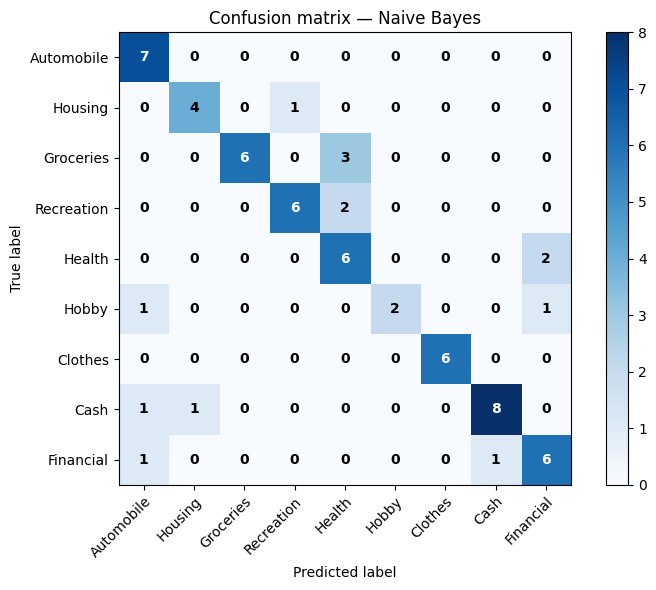


--- Logistic Regression ---
Accuracy: 0.8154

Classification report (precision, recall, F1 per category):
               precision    recall  f1-score   support

    Education       0.70      1.00      0.82         7
Entertainment       1.00      0.40      0.57         5
         Food       0.64      1.00      0.78         9
       Health       0.86      0.75      0.80         8
         Rent       1.00      0.75      0.86         8
       Salary       0.75      0.75      0.75         4
     Shopping       1.00      1.00      1.00         6
    Transport       0.80      0.80      0.80        10
    Utilities       1.00      0.75      0.86         8

     accuracy                           0.82        65
    macro avg       0.86      0.80      0.80        65
 weighted avg       0.85      0.82      0.81        65

Confusion matrix (rows=true, cols=predicted):
[[7 0 0 0 0 0 0 0 0]
 [0 2 1 1 0 0 0 1 0]
 [0 0 9 0 0 0 0 0 0]
 [0 0 2 6 0 0 0 0 0]
 [0 0 1 0 6 1 0 0 0]
 [1 0 0 0 0 3 0 0 0]
 [0

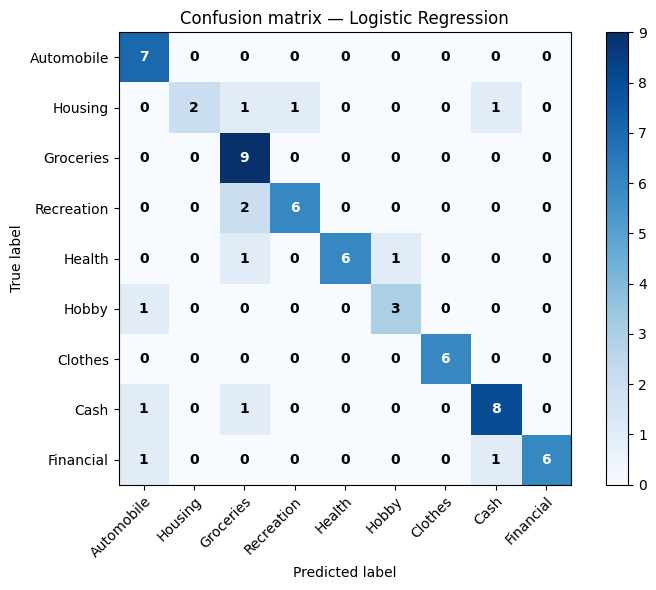


--- Random Forest ---
Accuracy: 0.7538

Classification report (precision, recall, F1 per category):
               precision    recall  f1-score   support

    Education       0.54      1.00      0.70         7
Entertainment       1.00      0.40      0.57         5
         Food       0.62      0.89      0.73         9
       Health       0.86      0.75      0.80         8
         Rent       1.00      0.75      0.86         8
       Salary       0.75      0.75      0.75         4
     Shopping       1.00      0.67      0.80         6
    Transport       0.73      0.80      0.76        10
    Utilities       1.00      0.62      0.77         8

     accuracy                           0.75        65
    macro avg       0.83      0.74      0.75        65
 weighted avg       0.82      0.75      0.76        65

Confusion matrix (rows=true, cols=predicted):
[[7 0 0 0 0 0 0 0 0]
 [0 2 1 1 0 0 0 1 0]
 [0 0 8 0 0 0 0 1 0]
 [0 0 2 6 0 0 0 0 0]
 [0 0 1 0 6 1 0 0 0]
 [1 0 0 0 0 3 0 0 0]
 [2 0 0 0

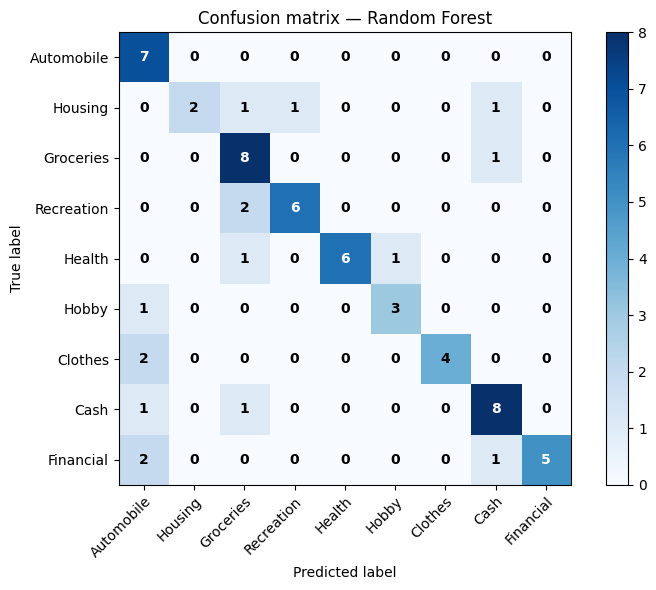

In [76]:
# Performance comparison: test all models on the test set
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=10, criterion="entropy", random_state=0),
}

# Category names for plot labels (optional; uses ids if not all present in data)
category_names = [
    "Automobile", "Housing", "Groceries", "Recreation", "Health",
    "Hobby", "Clothes", "Cash", "Financial", "Other"
]

def plot_confusion_matrix(cm, name, labels=None):
    """Draw confusion matrix as a heatmap."""
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    n = cm.shape[0]
    # Use names only if we have exactly n labels; otherwise use class indices
    if labels is not None and len(labels) >= n:
        tick_labels = labels[:n]
    else:
        tick_labels = [str(i) for i in range(n)]
    ax.set(xticks=np.arange(n), yticks=np.arange(n),
           xticklabels=tick_labels, yticklabels=tick_labels,
           title=f"Confusion matrix — {name}",
           ylabel="True label", xlabel="Predicted label")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
    fig.tight_layout()
    plt.show()

print("=" * 60)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification report (precision, recall, F1 per category):")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion matrix (rows=true, cols=predicted):")
    print(cm)
    # Draw confusion matrix
    plot_confusion_matrix(cm, name, category_names)

In [79]:
categories = {
    0:'Automobile and Transport',
    1:'Housing and Real-Estate',
    2:'Groceries',
    3:'Recreation and Leisure',
    4:'Health and Well Being',
    5:'Hobby and Knowledge',
    6:'Clothes and Equipment',
    7:'Cash and Credit',
    8:'Financial Services',
    9:'Other'
}

def get_category_by_id(id):
    # Classifier predicts string labels (e.g. 'Transport', 'Food'); categories dict uses int keys.
    if isinstance(id, str):
        return id
    return categories[id]

In [80]:
inputs = ['lidl', 'netto ))', 'netflix', 'kfc', 'rent', 'spotify']
predictions = classifier.predict(cv.transform(inputs))
{ inputs[id]: get_category_by_id(predictions[id]) for id in range(predictions.size) }

{'lidl': 'Food',
 'netto ))': 'Food',
 'netflix': 'Entertainment',
 'kfc': 'Food',
 'rent': 'Rent',
 'spotify': 'Food'}

In [81]:
# Quick date entry: categorize a free-text statement (e.g. "i spent 4k on netflix sub")
# Use the same preprocessing as training so the model sees consistent text.
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

def preprocess_for_model(raw_text):
    """Same cleaning as training: keep only letters/numbers, lower, stem, remove stopwords (en + da)."""
    text = re.sub(r'[^a-zA-Z0-9]', ' ', str(raw_text))
    text = text.lower().split()
    ps = PorterStemmer()
    en_stop = set(stopwords.words('english'))
    da_stop = set(stopwords.words('danish'))
    text = [ps.stem(w) for w in text if w not in en_stop and w not in da_stop]
    return ' '.join(text)

def predict_category(statement, clf=classifier, vectorizer=cv, category_map=categories):
    """Predict category for one statement (e.g. 'i spent 4k on netflix sub' -> Recreation and Leisure)."""
    preprocessed = preprocess_for_model(statement)
    X = vectorizer.transform([preprocessed])
    pred = clf.predict(X)[0]
    # Classifier returns string labels (e.g. 'Food', 'Entertainment'); category_map has int keys.
    if isinstance(pred, str):
        return pred
    return category_map.get(pred, 'Other')

# Demo: your quick-entry example (entertainment = Recreation and Leisure, id 3)
demo = "i spent 4k on spotify "
print(f"Statement: \"{demo}\"")
print(f"Predicted category: {predict_category(demo)}")

Statement: "i spent 4k on spotify "


ValueError: invalid literal for int() with base 10: 'Food'